# 183. Customers Who Never Order
https://leetcode.com/problems/customers-who-never-order/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| NOT IN Subquery | O(n + m) | O(m) | Simple, readable |
| LEFT JOIN + IS NULL | O(n + m) | O(n + m) | Join-based approach |
| NOT EXISTS | O(n * m) | O(1) | Correlated subquery |

## Methodology

This is a SQL problem. Find customers who never placed an order.
We select from Customers where the id is NOT IN the set of customerIds from Orders.
Alternatively, a LEFT JOIN with NULL check is equally efficient.

## Solutions

### C#

In [ ]:
// SQL Problem - Customers Who Never Order
// SQL Solution:
//
// SELECT name AS Customers
// FROM Customers
// WHERE id NOT IN (SELECT customerId FROM Orders);
//
// Alternative using LEFT JOIN:
//
// SELECT c.name AS Customers
// FROM Customers c
// LEFT JOIN Orders o ON c.id = o.customerId
// WHERE o.id IS NULL;

// C# programmatic equivalent
using System;
using System.Linq;
using System.Collections.Generic;

public class Solution
{
    public static List<string> CustomersWhoNeverOrder(
        List<(int id, string name)> customers,
        List<int> orderCustomerIds)
    {
        var orderedSet = new HashSet<int>(orderCustomerIds);
        return customers
            .Where(c => !orderedSet.Contains(c.id))
            .Select(c => c.name)
            .ToList();
    }
}

// Test
var customers = new List<(int, string)> { (1, "Joe"), (2, "Henry"), (3, "Sam"), (4, "Max") };
var orders = new List<int> { 3, 1 };
Console.WriteLine(string.Join(", ", Solution.CustomersWhoNeverOrder(customers, orders))); // Henry, Max

### Python

In [ ]:
// SQL Problem - Python programmatic equivalent
//
// def customers_who_never_order(customers, order_customer_ids):
//     ordered = set(order_customer_ids)
//     return [name for cid, name in customers if cid not in ordered]

### Go

In [ ]:
// SQL Problem - Go programmatic equivalent
//
// type Customer struct {
//     ID   int
//     Name string
// }
//
// func customersWhoNeverOrder(customers []Customer, orderCustIDs []int) []string {
//     ordered := make(map[int]bool)
//     for _, id := range orderCustIDs {
//         ordered[id] = true
//     }
//     var result []string
//     for _, c := range customers {
//         if !ordered[c.ID] {
//             result = append(result, c.Name)
//         }
//     }
//     return result
// }

### Rust

In [ ]:
// SQL Problem - Rust programmatic equivalent
//
// use std::collections::HashSet;
//
// fn customers_who_never_order(
//     customers: &[(i32, String)],
//     order_customer_ids: &[i32],
// ) -> Vec<String> {
//     let ordered: HashSet<i32> = order_customer_ids.iter().cloned().collect();
//     customers.iter()
//         .filter(|(id, _)| !ordered.contains(id))
//         .map(|(_, name)| name.clone())
//         .collect()
// }

## Example Scenarios

### 1. Common Case — Mixed Ordering Customers

**Input:** Customers: `{(1,'Joe'), (2,'Henry'), (3,'Sam'), (4,'Max')}`, Orders: `{(1,3), (2,1)}` (customerId)

Build a HashSet from order customerIds: `{3, 1}`. Check each customer: Joe (1) is in the set, Henry (2) is not, Sam (3) is in the set, Max (4) is not. Return `['Henry', 'Max']`.

**WHY it's useful:** Basic NOT IN with HashSet lookup. Time: $O(n + m)$ where $n$ = customers, $m$ = orders. Space: $O(m)$ for the set.

---

### 2. Slightly Complex — Repeat Orders from Same Customer

**Input:** Customers: `{(1,'Alice'), (2,'Bob'), (3,'Carol')}`, Orders: `{(1,1), (2,1), (3,1), (4,3)}`

Alice placed 3 orders, Carol placed 1. The HashSet of customerIds is `{1, 3}` — duplicates are absorbed. Bob (id=2) is not in the set. Only Bob is returned.

**WHY it's tricky:** Alice's 3 orders don't make her "more ordered" — the HashSet deduplicates. A LEFT JOIN approach would produce multiple rows for Alice and need DISTINCT.

---

### 3. Edge Case: Time Factor — Large Orders Table ($m = 10^6$)

**Input:** $n = 1{,}000$ customers, $m = 1{,}000{,}000$ orders. All 1,000 customers have at least one order.

NOT IN (HashSet): Build set in $O(m)$, check $n$ customers in $O(n)$. Total: $O(n + m) = O(1{,}001{,}000)$. NOT EXISTS (correlated subquery): $O(n \times m) = O(10^9)$ worst case.

**WHY it tests time:** The orders table is 1000x larger than customers. Approach choice matters critically — NOT IN with a HashSet keeps it linear.

---

### 4. Edge Case: Space Factor — No Orders at All

**Input:** $n = 100{,}000$ customers, $m = 0$ orders (empty table).

The HashSet from Orders is empty (0 bytes). Every customer passes the NOT IN check. Result contains all 100,000 customer names: $O(n)$ output space.

**WHY it tests space:** Maximum output size — every customer is returned. The NOT IN set is empty but the result list consumes $O(n)$ memory.

---

### 5. Almost-Impossible — NULL customerId in Orders (SQL Trap)

**Input:** Customers: `{(1,'Alpha'), (2,'Beta')}`, Orders: `{(1,NULL), (2,1)}`

SQL's 3-valued logic makes `WHERE id NOT IN (NULL, 1)` evaluate as `id != NULL AND id != 1`. Since `id != NULL` is always UNKNOWN, the entire WHERE clause returns no rows — even Beta (id=2) who genuinely never ordered!

**WHY it's extreme:** This is a classic SQL interview trap. `NOT IN` with NULLs silently returns empty. Use `LEFT JOIN + IS NULL` or `NOT EXISTS` to avoid this pitfall. The interviewer expects you to know this edge case.

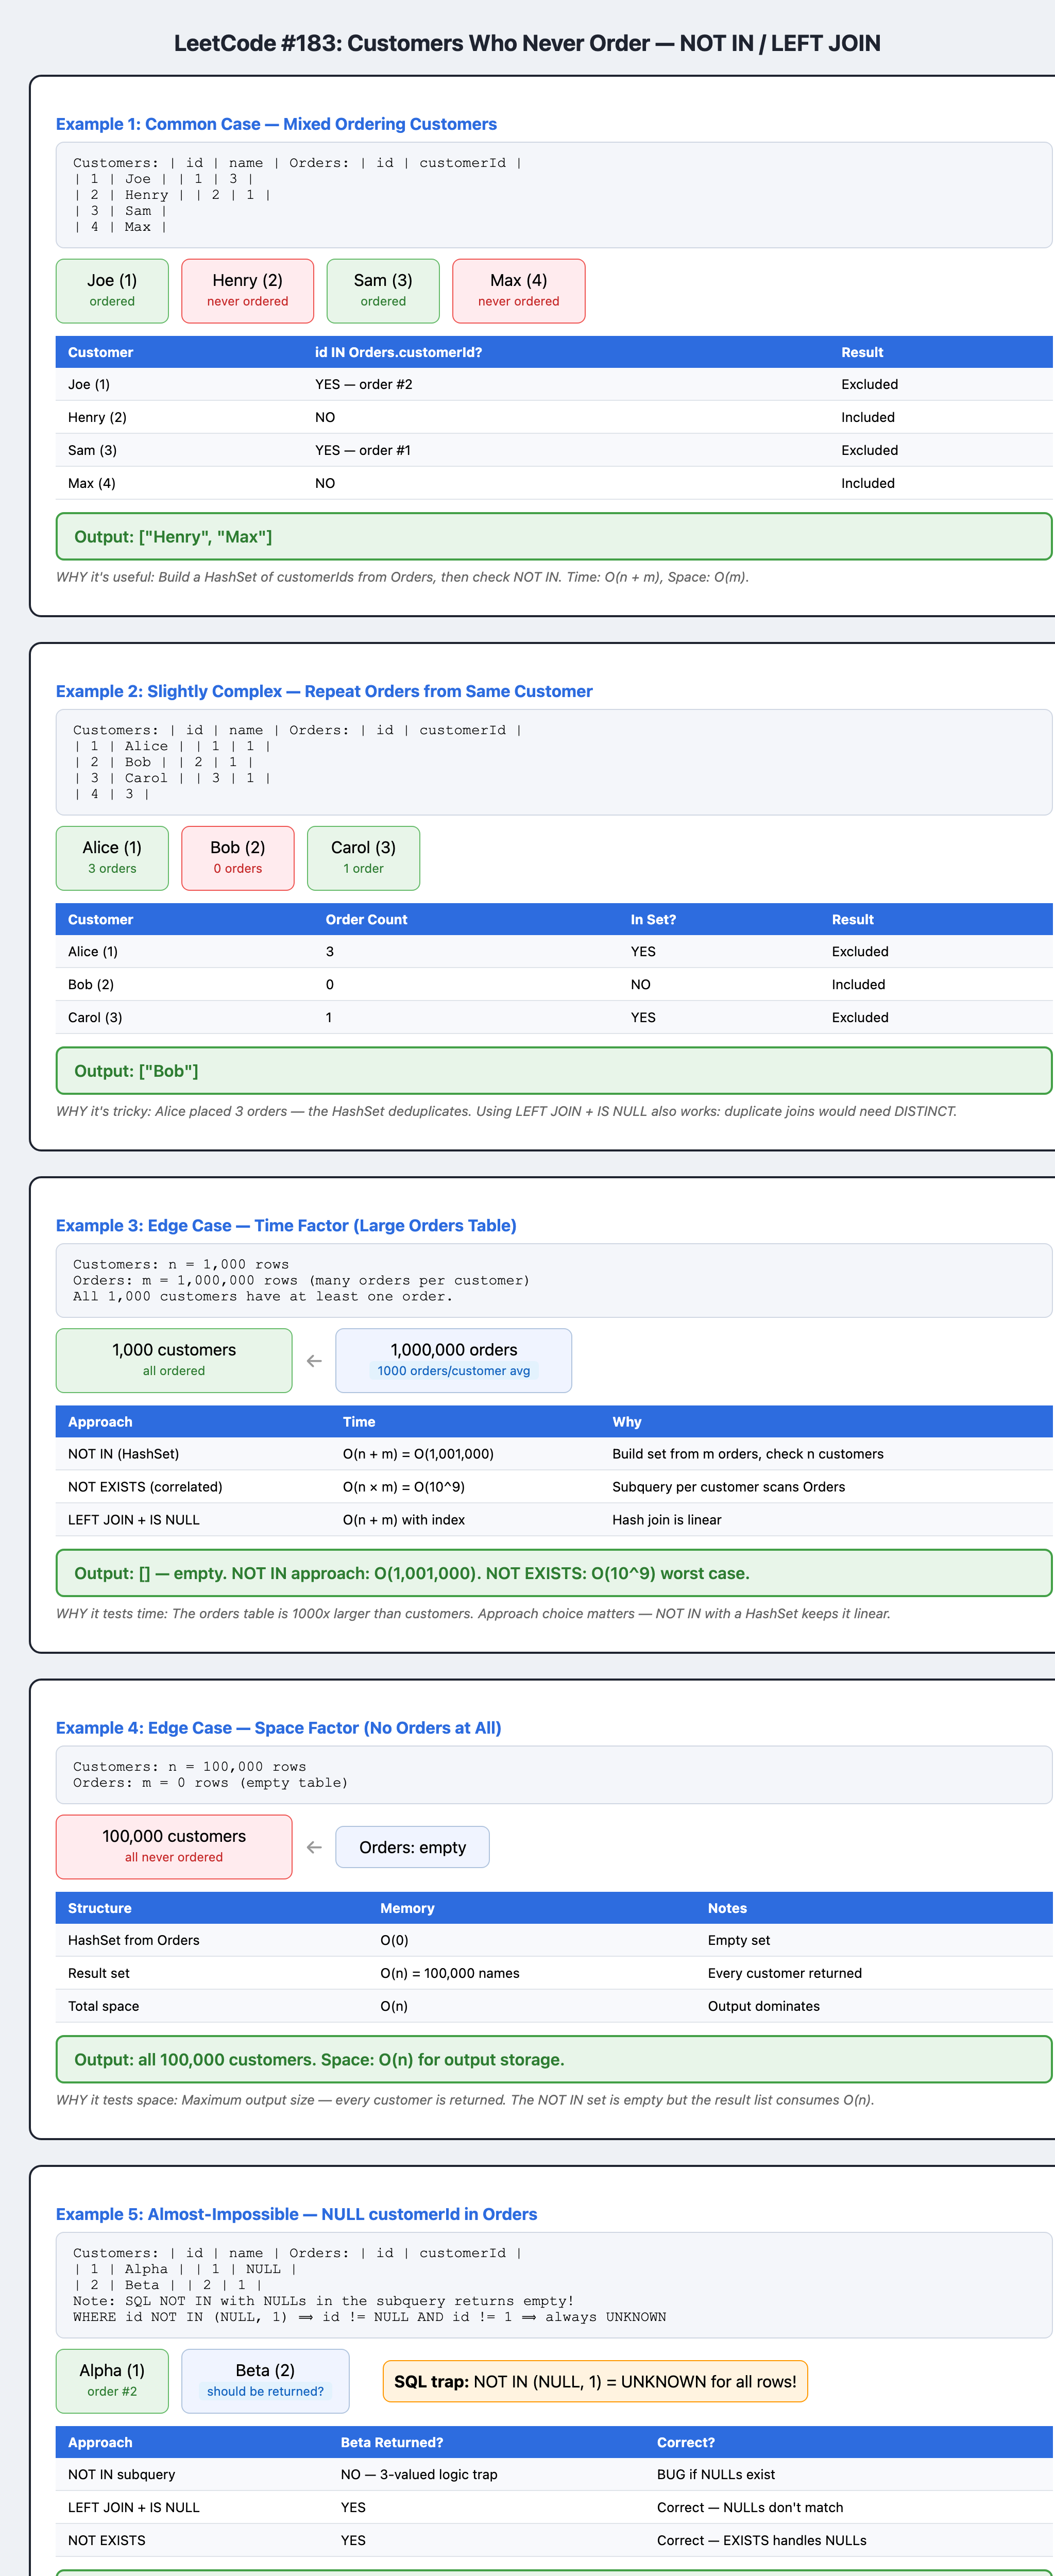